# pybela Tutorial 1: Streamer – Bela to python basics
This notebook is a tutorial for the Streamer class in the pybela python library. You can use the Streamer to stream data from Bela to python or vice versa. 

In this tutorial we will be looking at sending data from Bela to python. The Streamer allows you to start and stop streaming, to stream a given number of data points, to plot the data as it arrives, and to save and load the streamed data into `.txt` files. 

The complete documentation for the pybela library can be found in [https://belaplatform.github.io/pybela/](https://belaplatform.github.io/pybela/).

To run this tutorial, first copy the `bela-code/potentiometers` project onto Bela. If your Bela is connected to your laptop, you can run the cell below:

In [ ]:
!rsync -rvL ../bela-code/potentiometers root@bela.local:Bela/projects

Then you can compile and run the project using either the IDE or by running the following command in the Terminal:
```bash
ssh root@bela.local "make -C Bela stop Bela PROJECT=potentiometers run" 
```
(Running this on a jupyter notebook will block the cell until the program is stopped on Bela.)

### Setting up the circuit
In this example we will be using two potentiometers as our analog signals, but you can connect whichever sensors you like to analog channels 0 and 1.

Potentiometers have 3 pins. To connect a potentiometer to Bela, attach the left pin to the Bela 3.3V pin, the central pin to the desired analog input (e.g. 0) and the right pin to the Bela GND pin:

<p align="center">
<img src="potentiometers-circuit.png" width=800/>
</p>

### Taking a look at the Bela C++ code
If you take a look into the Bela code (in `bela-code/potentiometers/render.cpp`), you will see that the variables `pot1` and `pot2` are defined in a particular way:

```cpp
Watcher<float> pot1("pot1");
Watcher<float> pot2("pot2");
```

This means that the variables `pot1` and `pot2` are being "watched" and hence we can request their values to be streamed to this notebook using the pybela Streamer class. The watcher will stream a buffer containing timestamp and variable value information. Take a look at the `render` loop:

```cpp
void render(BelaContext *context, void *userData)
{
	for(unsigned int n = 0; n < context->audioFrames; n++) {
		if(gAudioFramesPerAnalogFrame && !(n % gAudioFramesPerAnalogFrame)) {
			
			uint64_t frames = context->audioFramesElapsed/gAudioFramesPerAnalogFrame + n/gAudioFramesPerAnalogFrame;
			Bela_getDefaultWatcherManager()->tick(frames); // watcher timestamps
			
			pot1 = analogRead(context,  n/gAudioFramesPerAnalogFrame, gPot1Ch);
			pot2 = analogRead(context,  n/gAudioFramesPerAnalogFrame, gPot2Ch);
			
		}
	}
}
```

we are reading the values of the potentiometer (with `analogRead()`) at every audio frame, and assigning them to their corresponding variable (`pot1` and `pot2`). In order for the Bela Watcher to know at which timestamp this happens, we need to "tick" the Watcher clock, we do this in line 30 with:
```cpp
			Bela_getDefaultWatcherManager()->tick(frames); // watcher timestamps
```

If you want to take a look at more advanced ways of watching variables, take a look at the Logger notebook. But enough with C++, let's take a look at the pybela Streamer class and its usage. 

### Getting started
Once you have the circuit set up, build and run the Bela project `potentiometers`. Once running, we are ready to interact with it form this notebook. We'll start by importing some necessary libraries and setting the `BOKEH_ALLOW_WS_ORIGIN` environment that will allow us to visualise the bokeh plots (comment/uncomment depending on if you are running this notebook from a jupyter notebook or VSCode).

In [1]:
import pandas as pd
from pybela import Streamer
import os
os.environ['BOKEH_ALLOW_WS_ORIGIN'] = "1t4j54lsdj67h02ol8hionopt4k7b7ngd9483l5q5pagr3j2droq" # uncomment if running on vscode
# os.environ['BOKEH_ALLOW_WS_ORIGIN'] = "localhost:8888" # uncomment if running on jupyter

AttributeError: module 'numpy' has no attribute 'bool8'

Now let's initialise the streamer and connect it to the Bela websocket. If the connection fails, make sure Bela is connected to your laptop and that the `potentiometer` project is running on Bela.

In [36]:
streamer = Streamer()
streamer.connect()

Running in Jupyter notebook. Enabling nest_asyncio.
Connection successful


1

Let's start by streaming the values of potentiometer 1 and 2. For that, we call `streamer.start_streaming(variables=["pot1", "pot2"])`. This will request the values of the variables `pot1` and `pot`. We can visualise those values as they arrive by plotting them using `streamer.plot_data(x_var="pot1", y_vars=["pot1", "pot2"], y_range=[0,1])`. The argument `x_var` determines which variable will provide the timestamps for the x axis, and the argument `y_vars` expects a list of variables that are currently being streamed or monitored. `y_range` determines the range of the y-axis.

In [4]:
streamer.start_streaming(variables=["pot1", "pot2"])
streamer.plot_data(x_var="pot1", y_vars=["pot1", "pot2"], y_range=[0, 1], rollover=10000)

Started streaming variables ['pot1', 'pot2']... Run stop_streaming() to stop streaming.


TypeError: publish_display_data() takes from 1 to 2 positional arguments but 3 positional arguments (and 1 keyword-only argument) were given

In [7]:
!pip install bokeh==2.4.3 panel==0.14.4 ipywidgets==7.7.2

  Using cached bokeh-2.4.3-py3-none-any.whl.metadata (14 kB)
  Using cached ipython_genutils-0.2.0-py2.py3-none-any.whl.metadata (755 bytes)
Using cached bokeh-2.4.3-py3-none-any.whl (18.5 MB)
Using cached ipython_genutils-0.2.0-py2.py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.7 MB/s  0:00:00
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupyterlab_widgets 3.0.16
    Uninstalling jupyterlab_widgets-3.0.16:
      Successfully uninstalled jupyterlab_widgets-3.0.16
  Attempting uninstall: bokeh╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [jupyterlab-widgets]
    Found existing installation: bokeh 3.9.0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [jupyterlab-widgets]
    Uninstalling bokeh-3.9.0:━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [bokeh]-widgets]
      Successfully uninstalled bokeh-3.9.05;237m╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [bokeh]
  Attempting uninstall: widgetsnbextension╺━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [bokeh]
    Found existing installati

You can stop streaming the values of potentiometer 1 and 2 by calling `streamer.stop_streaming(variables=["pot1", "pot2"])`. You can also call `streamer.stop_streaming()` which will stop streaming all the available variables in the watcher (in this case, both `pot1` and `pot2`).

In [ ]:
streamer.stop_streaming()


### Using `.wait` to stream data for a fixed amount of time
You can use the `.wait` method to stream data for a fixed amount of time. Note: you need to use `.wait` method instead of `time.sleep`, since the latter pauses the entire program (including the streaming tasks running in the background).

In [5]:
streamer.start_streaming(variables=["pot2"])
streamer.plot_data(x_var="pot2", y_vars=["pot2"], y_range=[0, 1])
streamer.wait(10)
streamer.stop_streaming()

Stopping previous streaming session...
Stopped streaming variables ['pot1', 'pot2']...
Started streaming variables ['pot2']... Run stop_streaming() to stop streaming.


TypeError: publish_display_data() takes from 1 to 2 positional arguments but 3 positional arguments (and 1 keyword-only argument) were given

In [41]:
# 1. 시각화 없이 '저장 모드'로 10초간 데이터만 쫙 빨아들입니다.
print("🔴 10초 동안 Trill Bar 위에서 손가락을 문지르고 뗐다 붙였다 해보세요!")

# 수정 포인트 1 & 2: 요청 변수명(touchLoc, touchSize) 변경, 파일명 변경
streamer.start_streaming(variables=["touchLoc", "touchSize"], saving_enabled=True, saving_filename="trill_10sec_test.txt")

# 2. 메인 화면은 멈춰있지만, 백그라운드에서 10초 동안 계속 수집합니다.
streamer.wait(20)

# 3. 10초가 지나면 깔끔하게 종료!
streamer.stop_streaming()

print("🟢 10초 수집 완료! Trill Bar 데이터가 안전하게 저장되었습니다.")

🔴 10초 동안 Trill Bar 위에서 손가락을 문지르고 뗐다 붙였다 해보세요!
Started streaming variables ['touchLoc', 'touchSize']... Run stop_streaming() to stop streaming.
Stopped streaming variables ['touchLoc', 'touchSize']...
🟢 10초 수집 완료! Trill Bar 데이터가 안전하게 저장되었습니다.


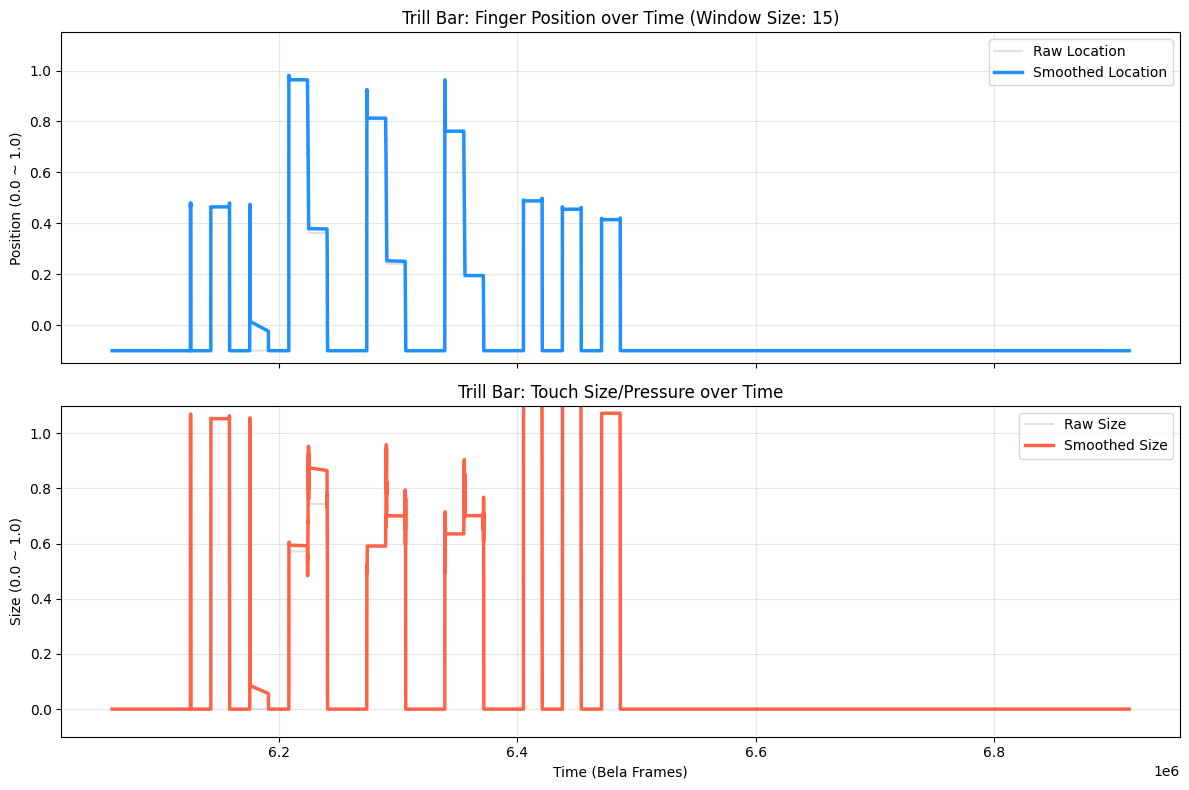

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 버퍼 큐를 1차원 리스트로 펴주는 함수
def flatten_buffers_queue(_buffer_queue):
    data_timestamps, data_values = [], []
    for _buffer in _buffer_queue:
        ref_timestamp = _buffer["ref_timestamp"]
        data_timestamps.extend([ref_timestamp + i for i in range(len(_buffer["data"]))])
        data_values.extend(_buffer["data"])
    return data_timestamps, data_values

# 2. 파일 로드 (streamer 객체가 연결되어 있다고 가정)
raw_loc = streamer.load_data_from_file("touchLoc_trill_10sec_test.txt")
raw_size = streamer.load_data_from_file("touchSize_trill_10sec_test.txt")

# 3. 데이터 Flatten 처리
loc_times, loc_vals = flatten_buffers_queue(raw_loc)
size_times, size_vals = flatten_buffers_queue(raw_size)

# 4. 데이터프레임 구조화
df_loc = pd.DataFrame({"timestamp": loc_times, "location": loc_vals})
df_size = pd.DataFrame({"timestamp": size_times, "size": size_vals})

# ========================================================
# 🚀 핵심: 이동 평균(Moving Average) 필터 적용
window_size = 15 # 이 값을 5(덜 부드러움) ~ 30(매우 부드러움) 사이로 조절해 보세요.

df_loc["smooth_location"] = df_loc["location"].rolling(window=window_size, min_periods=1).mean()
df_size["smooth_size"] = df_size["size"].rolling(window=window_size, min_periods=1).mean()
# ========================================================

# 5. 시각화 (원본은 연하게, 필터링된 데이터는 진하게 겹쳐서 출력)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# [상단 차트] 터치 위치 (Touch Location)
# 원본 계단형 데이터 (회색 배경)
ax1.plot(df_loc["timestamp"], df_loc["location"], color='lightgray', linewidth=1.5, label='Raw Location', alpha=0.7)
# 스무딩 처리된 데이터 (파란색 메인)
ax1.plot(df_loc["timestamp"], df_loc["smooth_location"], color='dodgerblue', linewidth=2.5, label='Smoothed Location')

ax1.set_title(f"Trill Bar: Finger Position over Time (Window Size: {window_size})")
ax1.set_ylabel("Position (0.0 ~ 1.0)")
ax1.set_ylim(-0.15, 1.15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# [하단 차트] 터치 크기/압력 (Touch Size)
# 원본 계단형 데이터 (회색 배경)
ax2.plot(df_size["timestamp"], df_size["size"], color='lightgray', linewidth=1.5, label='Raw Size', alpha=0.7)
# 스무딩 처리된 데이터 (빨간색 메인)
ax2.plot(df_size["timestamp"], df_size["smooth_size"], color='tomato', linewidth=2.5, label='Smoothed Size')

ax2.set_title("Trill Bar: Touch Size/Pressure over Time")
ax2.set_xlabel("Time (Bela Frames)")
ax2.set_ylabel("Size (0.0 ~ 1.0)")
ax2.set_ylim(-0.1, 1.1)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

#### Scheduling streaming sessions
You can schedule a streaming session to start and stop at a specific time using the `schedule_streaming()` method. This method takes the same arguments as `start_streaming()`, but it also takes a `timestamps` and `durations` argument.

In [ ]:
latest_timestamp = streamer.get_latest_timestamp() # get the latest timestamp
sample_rate = streamer.sample_rate # get the sample rate
start_timestamp = latest_timestamp + sample_rate # start streaming 1 second after the latest timestamp
duration = sample_rate # stream for 2 seconds

streamer.schedule_streaming(
    variables=["pot1", "pot2"],
    timestamps=[start_timestamp, start_timestamp],
    durations=[duration, duration],
    saving_enabled=True)

### Note on streaming variables assigned at low frequency rates
The data buffers sent from Bela have fixed sizes. The buffers will only be sent when they are full, unless you use the streaming with scheduling feature (explained below). If the variables you are streaming are assigned at too low rates, these buffers will take too long to fill up and the data will be either sent to python with a delay or not sent at all (if the buffer is never filled). For example, floats using dense timestamping are sent in buffers of 1024 values. If the float variable is assigned once every 12 milliseconds, filling a buffer will take 1024/(1/0.012) = 12.3 seconds. 
Hence, the streaming mode is not ideal for variables assigned at low rates, but rather for variables that are assigned quite frequently (e.g. at audio rate). If you want to stream variables that are assigned at lower rates, you can use the streaming with scheduling feature, or monitor or log the variable instead.

### Retrieving the data
You can access the data streamed in `streamer.streaming_buffers_data`. We can use the pandas data manipulation library for printing the data onto a table:

In [ ]:
df = pd.DataFrame(streamer.streaming_buffers_data["pot2"])
df.head() # head shows only the first 5 rows

As you can see, `streaming_buffers_data` only retrieves the variable values but not its timestamps. If you want to retrieve the timestamps, you can access `streaming_buffers_queue["pot2"]`. This will return a list in which every item is a timestamped buffer:

In [ ]:
streamer.streaming_buffers_queue["pot2"][0]

In the buffer `ref_timestamp` corresponds to the timestamp of the first value of the buffer (`streaming_buffers_queue["pot2"][0]["data"][0]`). If the Bela Watcher is ticked once per analog frame (as it is the case in the `potentiometer` code) and the variable `pot2` is assigned also once per analog frame, the timestamps of the rest of the values in the data buffer correspond to the increasing timestamps:

In [ ]:
data_timestamps = []
data_values = []

def flatten_buffers_queue(_buffer_queue):
    for _buffer in _buffer_queue:
        ref_timestamp = _buffer["ref_timestamp"]
        data_timestamps.extend([ref_timestamp + i for i in range(len(_buffer["data"]))])
        data_values.extend(_buffer["data"])
    
    return data_timestamps, data_values

data_timestamps, data_values = flatten_buffers_queue(streamer.streaming_buffers_queue["pot2"])
    
df = pd.DataFrame({"timestamp": data_timestamps, "value": data_values})
df.head()

More advanced timestamping methods will be shown in the tutorial notebook `7_Sparse_timestamping.ipynb`

There is a limited amount of data that is stored in the streamer. This quantity can be modified by changing the buffer queue length. The streamer receives the data in buffers of fixed length that get stored in a queue that also has a fixed length. You can calculate the maximum amount of data the streamer can store for each variable:

note: `streamer.watcher_vars` returns information of the variables available in the watcher, that is, variables that have been defined within the Watcher class in the Bela code and that are available for streaming, monitoring or logging.

In [ ]:
print(f"Buffer queue length: {streamer.streaming_buffers_queue_length}")

for var in streamer.watcher_vars: 
    print(f'Variable: {var["name"]}, buffer length: {var["data_length"]}, max data stored in streamer: {var["data_length"]*streamer.streaming_buffers_queue_length}')

You can also modify the queue length:

In [ ]:
streamer.streaming_buffers_queue_length = 10

### Saving the streamed data
Every time you start a new streaming session (e.g. you call `start_streaming()` or `stream_n_values()`), the data stored in the streamer from the previous streaming session will be deleted. If you want to store the streamed data, you can do so by setting `saving_enabled=True` when calling `start_streaming()` or `stream_n_values()`:

In [ ]:
streamer.start_streaming(variables=[var["name"] for var in streamer.watcher_vars], saving_enabled=True, saving_filename="test.txt")
streamer.wait(3)
streamer.stop_streaming()

You can load the data stored using the `load_data_from_file` method. This will return the buffers queue. Again, we can flatten it using the `flatten_buffers_queue()` function we defined above:

In [ ]:
data_timestamps, data_values = flatten_buffers_queue(streamer.load_data_from_file("pot1_test.txt"))

df=pd.DataFrame({"timestamp": data_timestamps, "value": data_values})
df.head()